# Umsatzprognose

Dieses Notebook zeigt, wie viel Umsatz aus den Projekten zu erwarten ist, die bereits
in Clockodo angelegt sind. Es liest die Daten nur; es verändert in Clockodo nichts.

**So wird es benutzt:** oben im Menü *Laufzeit → Alle ausführen*, dann von oben nach
unten lesen. Der Abruf dauert etwa eine halbe Minute. Alle Diagramme sind interaktiv –
mit dem Mauszeiger über einem Balken stehen die genauen Zahlen.

In [1]:
try:
    import google.colab

    PAKET_URL = "git+https://github.com/it-agile/umsatzprognose-clockodo.git"

    !pip install --quiet "$PAKET_URL"
    !pip install --quiet --force-reinstall --no-deps "$PAKET_URL"
except ImportError:
    print("Lokale Installation")

Installationszelle Dashboard, Stand 2026-08-24 | lokale Installation


## Daten abrufen

Die Zugangsdaten kommen in Colab aus der Secrets-Verwaltung (Schlüssel-Symbol in der
linken Seitenleiste), lokal aus der Datei `.env`.

In [2]:
from umsatzprognose import Dashboard

dashboard = await Dashboard.laden_async()
print(f"Daten geladen. Stand der Auswertung: {dashboard.stichtag:%d.%m.%Y}")

Stand der Auswertung: 27.08.2026


## Überblick

Links der tatsächlich erzielte Umsatz der vergangenen zwölf abgeschlossenen Monate,
rechts das Volumen, das aus laufenden Projekten noch abgerufen werden kann.

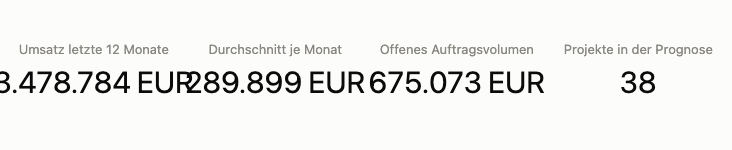

In [3]:
dashboard.kennzahlen()

## Umsatz je Monat

Alle Buchungen des jeweiligen Monats, auch die ohne Projektbezug. Der letzte Balken
der Historie ist der laufende Monat.

Rechts daran schließt sich der Prognosehorizont an: 
* **bereits gebuchter** Umsatz je Monat
* **prognostizierter** Umsatz obendrauf in gedämpfter Farbe. 
Der dünne Balken am oberen Rand zeigt, wie weit die vorsichtigeren 85-%- und 95-%-Schätzungen darunter liegen.

In [4]:
dashboard.simuliere(monate=3)

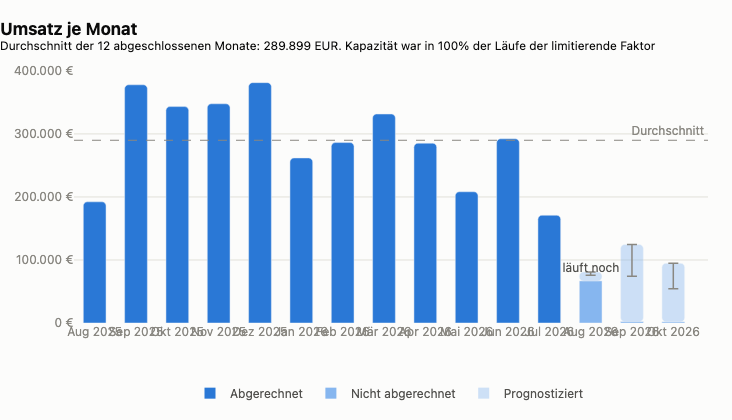

In [5]:
dashboard.umsatzverlauf()

Dieselben Zahlen zum Nachlesen:

In [6]:
dashboard.umsatztabelle()

,Monat,Abgerechnet,Nicht abgerechnet,Prognostiziert,Summe
0,Aug 2025,"192.244,01 EUR",,,"192.244,01 EUR"
1,Sep 2025,"377.920,75 EUR",,,"377.920,75 EUR"
2,Okt 2025,"343.313,58 EUR",,,"343.313,58 EUR"
3,Nov 2025,"347.784,97 EUR",,,"347.784,97 EUR"
4,Dez 2025,"381.333,31 EUR",,,"381.333,31 EUR"
5,Jan 2026,"261.845,81 EUR",,,"261.845,81 EUR"
6,Feb 2026,"286.251,10 EUR",,,"286.251,10 EUR"
7,Mär 2026,"331.558,13 EUR",,,"331.558,13 EUR"
8,Apr 2026,"285.249,57 EUR",,,"285.249,57 EUR"
9,Mai 2026,"208.201,79 EUR",,,"208.201,79 EUR"


## Offenes Auftragsvolumen

Je Projekt der Teil des beauftragten Volumens, der noch nicht verbraucht ist.

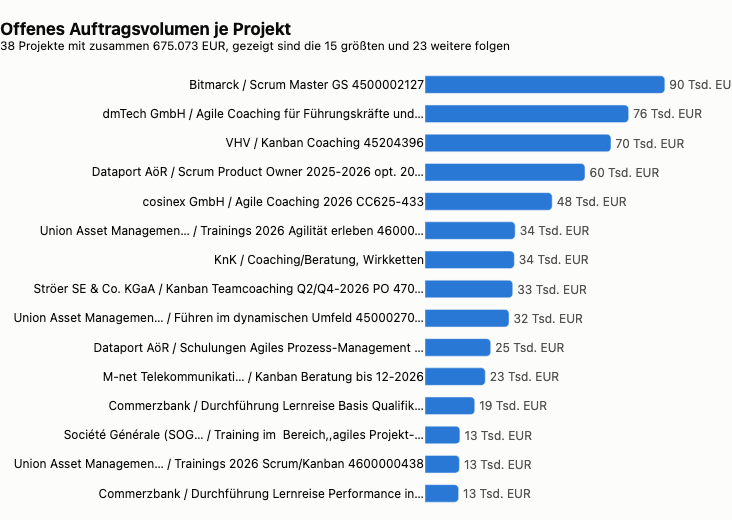

In [7]:
dashboard.restvolumen_je_projekt()

## Stundensatz für Projekte ohne Umsatz hinterlegen

Manche Projekte oben haben gebuchte Zeit, aber keinen Umsatz - ihr Stundensatz ist 0.
Ohne eine Korrektur bricht die spätere Umrechnung von Euro in Stunden an dieser Stelle.
Betroffene Projekte stehen im Hinweis "Stundensatz 0" oben, mit Namen.

Für jedes betroffene Projekt lässt sich hier ein plausibler Stundensatz nachtragen -
Projektname wie in der Hinweistabelle, Satz in Euro je Stunde. Die Zeile bleibt ohne
Wirkung, solange kein Projekt betroffen ist.

In [8]:
# Projektname wie in der Hinweistabelle oben, Satz in Euro je Stunde. Beispiel:
# stundensatz_korrekturen = {"Beispielprojekt": 95.0}
stundensatz_korrekturen = {}

dashboard.stundensatz_uebersteuern(stundensatz_korrekturen)

Zur Kontrolle: der Hinweis "Stundensatz 0" verschwindet für die eingetragenen Projekte.

## Was zu den Zahlen zu wissen ist

Nicht jedes Projekt lässt sich auswerten. Hier steht, welche Fälle aufgetreten sind
und was sie für die Zahlen oben bedeuten.

In [9]:
dashboard.hinweise()

,Hinweis,Betroffen,Projekte
0,"Auf einen Kunden ohne Projekt gebucht: 6,0 h u...",,
1,Aktive Projekte ohne bezifferbares Auftragsvol...,76,"ACC, A-CSM, A-CSPO, Agentic Prototyping für Pr..."
2,Aktive Projekte mit überschrittenem Budget - s...,1,Beratung Koordinationsebene / Nave
3,"Projekte, die als abgeschlossen markiert und t...",1,Beratung Koordinationsebene / Nave
4,Projekte im Prognose-Scope ohne erfasste Zeit ...,3,"Training im Bereich,,agiles Projekt- und Por..."
5,Projekte im Prognose-Scope mit Stundensatz 0 -...,2,"Inhouse CSPO, Leadership Circle Profile"
6,Projekte im Prognose-Scope mit automatischem A...,3,"Kanban Coaching 45204396 (31.12.2026), Kanban ..."
7,"Projekte im Prognose-Scope, auf die im Betrach...",2,"Scrum Grundlagenschulung Nachwuchskräfte, LCP ..."
8,Die Abrufquote-Verteilung ist aus 2638 Projekt...,,
9,Nach dem Stichtagsmonat datierte Buchungen übe...,1,Société Générale (SOGECAP S.A.) / Training im ...
